In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
Clean_Data = pd.read_excel('2023_Data_BiomassGasification_NED.xlsx', sheet_name='Clean Data')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
Clean_Data

,ID,feed_type,feed_shape,feed_particle_size,feed_LHV,C,H,N,S,O,...,CO2,CH4,C2Hn,gas_LHV,gas_tar,gas_yield,char_yield,CGE,CCE,Reference
0,1,municipal solid waste,pellets,5,19.45,59.39,8.57,0.93,0.27,32.30,...,13.36,4.18,2.19,5.39,73.00,1.62,NaN,53.00,70.00,"Arena, Fuel 2014, 117, 528-536"
1,2,municipal solid waste,pellets,5,19.45,59.39,8.57,0.93,0.27,32.30,...,15.69,4.20,2.72,5.65,47.00,1.73,NaN,56.00,80.00,"Arena, Fuel 2014, 117, 528-536"
2,3,municipal solid waste,pellets,5,19.45,59.39,8.57,0.93,0.27,32.30,...,12.28,4.57,2.14,5.55,58.00,1.72,NaN,58.00,75.00,"Arena, Fuel 2014, 117, 528-536"
3,4,municipal solid waste,pellets,5,19.45,59.39,8.57,0.93,0.27,32.30,...,12.83,4.35,2.05,5.16,39.00,1.91,NaN,61.00,81.00,"Arena, Fuel 2014, 117, 528-536"
4,5,municipal solid waste,pellets,5,19.45,59.39,8.57,0.93,0.27,32.30,...,14.04,3.33,1.78,4.91,5.00,2.04,NaN,61.00,92.00,"Arena, Fuel 2014, 117, 528-536"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,404,sewage sludge,particles,2,13.25,52.28,7.82,6.67,1.90,31.33,...,31.44,8.06,0.66,9.23,NaN,NaN,NaN,80.41,67.07,"Yong-Seong Jeong et al.,Renewable Energy 185 2..."
404,405,sewage sludge,particles,2,13.25,52.28,7.82,6.67,1.90,31.33,...,16.38,2.62,0.01,4.05,NaN,NaN,NaN,61.23,62.42,"Yong-Seong Jeong et al.,Renewable Energy 185 2..."
405,406,sewage sludge,particles,2,13.25,52.28,7.82,6.67,1.90,31.33,...,15.81,3.43,0.02,4.71,NaN,NaN,NaN,62.60,57.36,"Yong-Seong Jeong et al.,Renewable Energy 185 2..."
406,407,sewage sludge,particles,2,13.25,52.28,7.82,6.67,1.90,31.33,...,16.10,2.95,0.01,4.40,NaN,NaN,NaN,61.10,57.64,"Yong-Seong Jeong et al.,Renewable Energy 185 2..."


In [6]:
input_var = ['feed_type', 'feed_shape', 'feed_particle_size', 'feed_LHV', 'C', 'H', 'O', 'N', 'S', 'O', 'feed_ash', 'feed_moisture', 'feed_VM', 'feed_FC', 'feed_cellulose', 'feed_hemicellulose', 'feed_lignin', 'temperature', 'operating_condition', 'operating_pressure', 'residence_time', 'Steam/Biomass', 'ER', 'gasifying_agent', 'reactor_type', 'bed_material', 'catalyst', 'scale']
clean_input = Clean_Data.loc[:, Clean_Data.columns.isin(input_var)]
clean_input


,feed_type,feed_shape,feed_particle_size,feed_LHV,C,H,N,S,O,feed_ash,...,operating_condition,operating_pressure,residence_time,Steam/Biomass,ER,gasifying_agent,reactor_type,bed_material,catalyst,scale
0,municipal solid waste,pellets,5,19.45,59.39,8.57,0.93,0.27,32.30,20.69,...,continuous,NaN,120.00,NaN,0.26,air,fluidised bed,olivine,1.00,pilot-scale (400 kW_th)
1,municipal solid waste,pellets,5,19.45,59.39,8.57,0.93,0.27,32.30,20.69,...,continuous,NaN,120.00,NaN,0.26,air,fluidised bed,olivine,1.00,pilot-scale (400 kW_th)
2,municipal solid waste,pellets,5,19.45,59.39,8.57,0.93,0.27,32.30,20.69,...,continuous,NaN,120.00,NaN,0.27,air,fluidised bed,olivine,1.00,pilot-scale (400 kW_th)
3,municipal solid waste,pellets,5,19.45,59.39,8.57,0.93,0.27,32.30,20.69,...,continuous,NaN,120.00,NaN,0.30,air,fluidised bed,olivine,1.00,pilot-scale (400 kW_th)
4,municipal solid waste,pellets,5,19.45,59.39,8.57,0.93,0.27,32.30,20.69,...,continuous,NaN,120.00,NaN,0.32,air,fluidised bed,olivine,1.00,pilot-scale (400 kW_th)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,sewage sludge,particles,2,13.25,52.28,7.82,6.67,1.90,31.33,42.59,...,continuous,NaN,33.00,0.67,0.44,steam/oxygen,fluidised bed,NaN,NaN,pilot-scale
404,sewage sludge,particles,2,13.25,52.28,7.82,6.67,1.90,31.33,42.59,...,continuous,NaN,280.00,NaN,0.41,air,fluidised bed,NaN,NaN,pilot-scale
405,sewage sludge,particles,2,13.25,52.28,7.82,6.67,1.90,31.33,42.59,...,continuous,NaN,225.00,NaN,0.33,air,fluidised bed,NaN,NaN,pilot-scale
406,sewage sludge,particles,2,13.25,52.28,7.82,6.67,1.90,31.33,42.59,...,continuous,NaN,242.00,NaN,0.35,air,fluidised bed,NaN,NaN,pilot-scale


In [7]:
output_var = ['N2', 'H2', 'CO', 'CO2', 'CH4', 'C2Hn', 'gas_LHV', 'gas_tar', 'gas_yield', 'char_yield', 'CGE', 'CCE']
clean_output = Clean_Data.loc[:, Clean_Data.columns.isin(output_var)]
clean_output

,N2,H2,CO,CO2,CH4,C2Hn,gas_LHV,gas_tar,gas_yield,char_yield,CGE,CCE
0,61.77,8.48,9.74,13.36,4.18,2.19,5.39,73.00,1.62,NaN,53.00,70.00
1,60.64,7.11,8.98,15.69,4.20,2.72,5.65,47.00,1.73,NaN,56.00,80.00
2,61.67,8.44,10.47,12.28,4.57,2.14,5.55,58.00,1.72,NaN,58.00,75.00
3,61.86,8.24,10.40,12.83,4.35,2.05,5.16,39.00,1.91,NaN,61.00,81.00
4,60.66,7.08,12.73,14.04,3.33,1.78,4.91,5.00,2.04,NaN,61.00,92.00
...,...,...,...,...,...,...,...,...,...,...,...,...
403,3.05,38.79,18.01,31.44,8.06,0.66,9.23,NaN,NaN,NaN,80.41,67.07
404,52.61,16.75,11.63,16.38,2.62,0.01,4.05,NaN,NaN,NaN,61.23,62.42
405,50.10,18.75,11.90,15.81,3.43,0.02,4.71,NaN,NaN,NaN,62.60,57.36
406,51.51,18.60,10.83,16.10,2.95,0.01,4.40,NaN,NaN,NaN,61.10,57.64


In [8]:
clean_input.describe()

,feed_LHV,C,H,N,S,O,feed_ash,feed_moisture,feed_VM,feed_FC,feed_cellulose,feed_hemicellulose,feed_lignin,temperature,residence_time,Steam/Biomass,ER,catalyst
count,408.00,408.00,408.00,408.00,375.00,408.00,408.00,408.00,360.00,318.00,28.00,28.00,28.00,408.00,156.00,136.00,335.00,308.00
mean,19.27,53.16,7.12,1.05,0.34,37.99,8.76,7.64,77.11,14.23,39.42,20.91,24.99,805.01,89.92,0.97,0.29,0.27
std,8.11,10.91,2.30,1.82,0.49,12.80,12.48,5.99,10.57,5.62,5.08,4.67,5.39,71.77,94.17,0.71,0.10,0.44
min,11.50,40.07,3.79,0.00,0.00,0.00,0.27,0.00,52.03,0.00,29.60,14.00,14.00,553.00,6.00,0.00,0.09,0.00
25%,14.47,48.32,5.90,0.15,0.00,33.75,1.00,5.13,67.95,11.53,37.53,18.90,23.84,770.00,40.00,0.50,0.23,0.00
50%,18.08,50.00,6.25,0.44,0.10,42.20,2.05,7.65,80.30,14.77,38.50,19.50,25.90,800.00,40.00,0.80,0.30,0.00
75%,19.45,53.31,7.12,0.97,0.57,44.71,13.90,9.34,83.17,17.16,43.50,24.40,26.68,850.00,80.00,1.22,0.32,1.00
max,45.10,86.03,14.23,7.32,1.90,53.40,44.00,51.02,99.00,31.80,46.20,29.60,33.00,1050.00,403.00,4.04,0.87,1.00


In [9]:
clean_output.describe()

,N2,H2,CO,CO2,CH4,C2Hn,gas_LHV,gas_tar,gas_yield,char_yield,CGE,CCE
count,408.00,408.00,405.00,405.00,405.00,329.00,408.00,193.00,292.00,83.00,299.00,295.00
mean,39.27,20.83,18.84,14.90,4.60,1.58,7.14,29.89,1.93,97.43,57.56,67.39
std,25.02,14.93,8.98,6.46,3.41,1.61,3.29,47.85,1.15,77.08,24.52,22.85
min,0.00,3.10,2.20,0.90,0.04,0.00,1.30,0.00,0.49,3.60,0.45,0.56
25%,2.31,9.57,12.50,11.00,2.10,0.01,4.40,4.30,1.27,24.20,43.05,57.75
50%,50.00,17.00,18.00,14.10,3.50,1.19,5.95,13.47,1.66,90.00,58.00,71.60
75%,58.28,28.00,22.72,17.56,7.30,2.50,9.95,35.71,2.17,167.13,71.05,80.93
max,74.90,71.50,50.00,38.25,16.00,9.50,15.60,364.00,6.19,301.52,122.87,126.89


In [10]:
drop_input_columns = ['feed_cellulose', 'feed_hemicellulose', 'feed_lignin', 'residence_time', 'operating_pressure']
drop_output_columns = ['CCE', 'CGE', 'char_yield']
clean_input_dropped = clean_input.drop(drop_input_columns, axis=1).copy()
clean_output_dropped = clean_output.drop(drop_output_columns, axis=1).copy()

In [11]:
continuous_var = ['feed_particle_size', 'feed_LHV', 'C', 'H', 'O', 'N', 'S', 'feed_ash', 'feed_moisture', 'feed_VM', 'feed_FC', 'temperature', 'Steam/Biomass', 'ER']
clean_input_cont = clean_input_dropped[continuous_var]
clean_input_cat = clean_input_dropped.drop(continuous_var, axis=1)
print(clean_input_cont.columns)
print(clean_input_cat.columns)

Index(['feed_particle_size', 'feed_LHV', 'C', 'H', 'O', 'N', 'S', 'feed_ash',
       'feed_moisture', 'feed_VM', 'feed_FC', 'temperature', 'Steam/Biomass',
       'ER'],
      dtype='object')
Index(['feed_type', 'feed_shape', 'operating_condition', 'gasifying_agent',
       'reactor_type', 'bed_material', 'catalyst', 'scale'],
      dtype='object')


Preliminary analysis

In [12]:
# Define thresholds for when correlation coefficients are considered significant
pearson_corr_threshold = 0.6
spearman_corr_threshold = 0.6

Pearson correlation coefficient for continous predictor variables


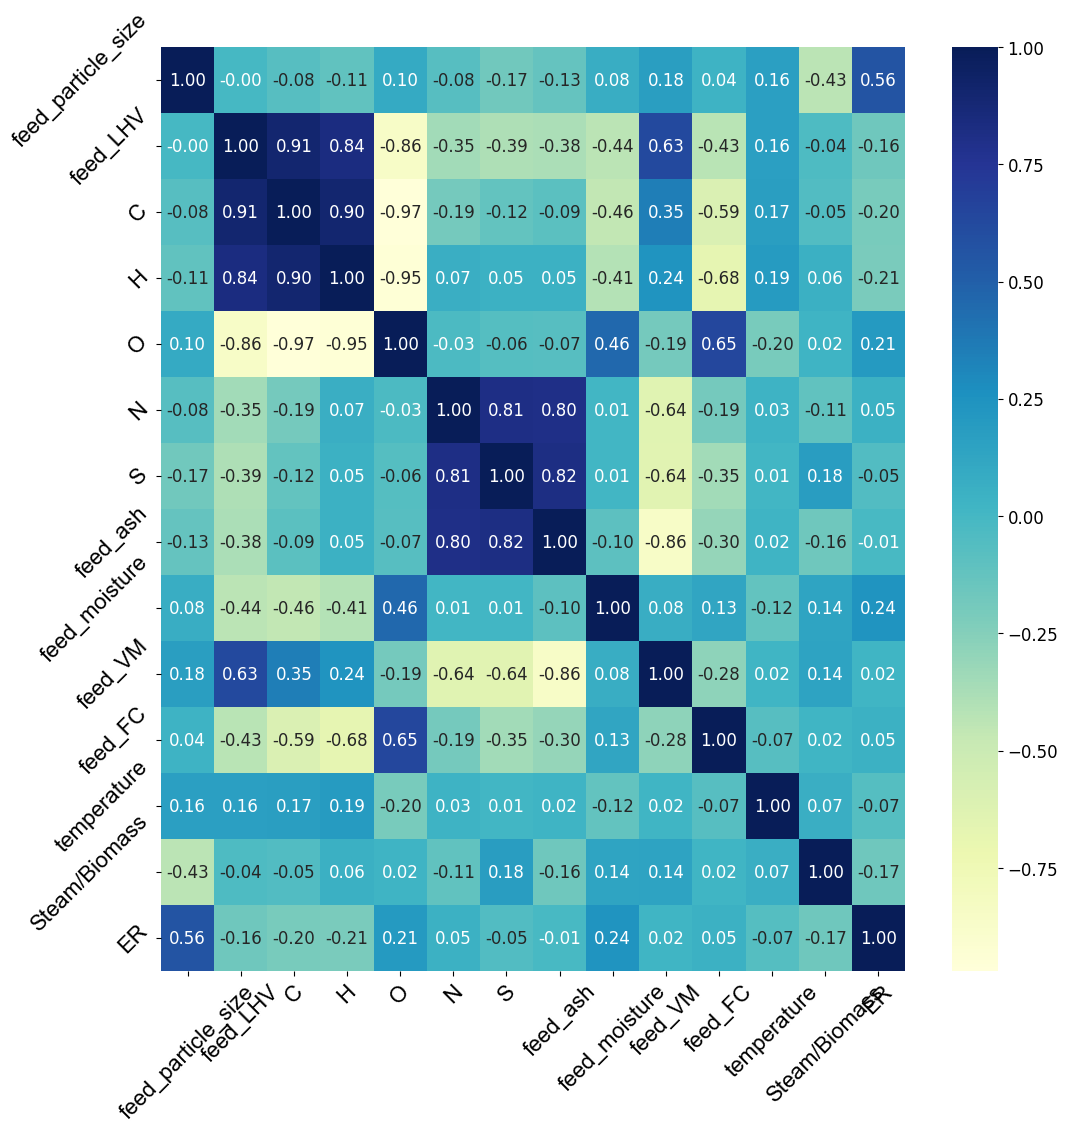

Show highly correlated values with an absolute value greater than 0.6 only


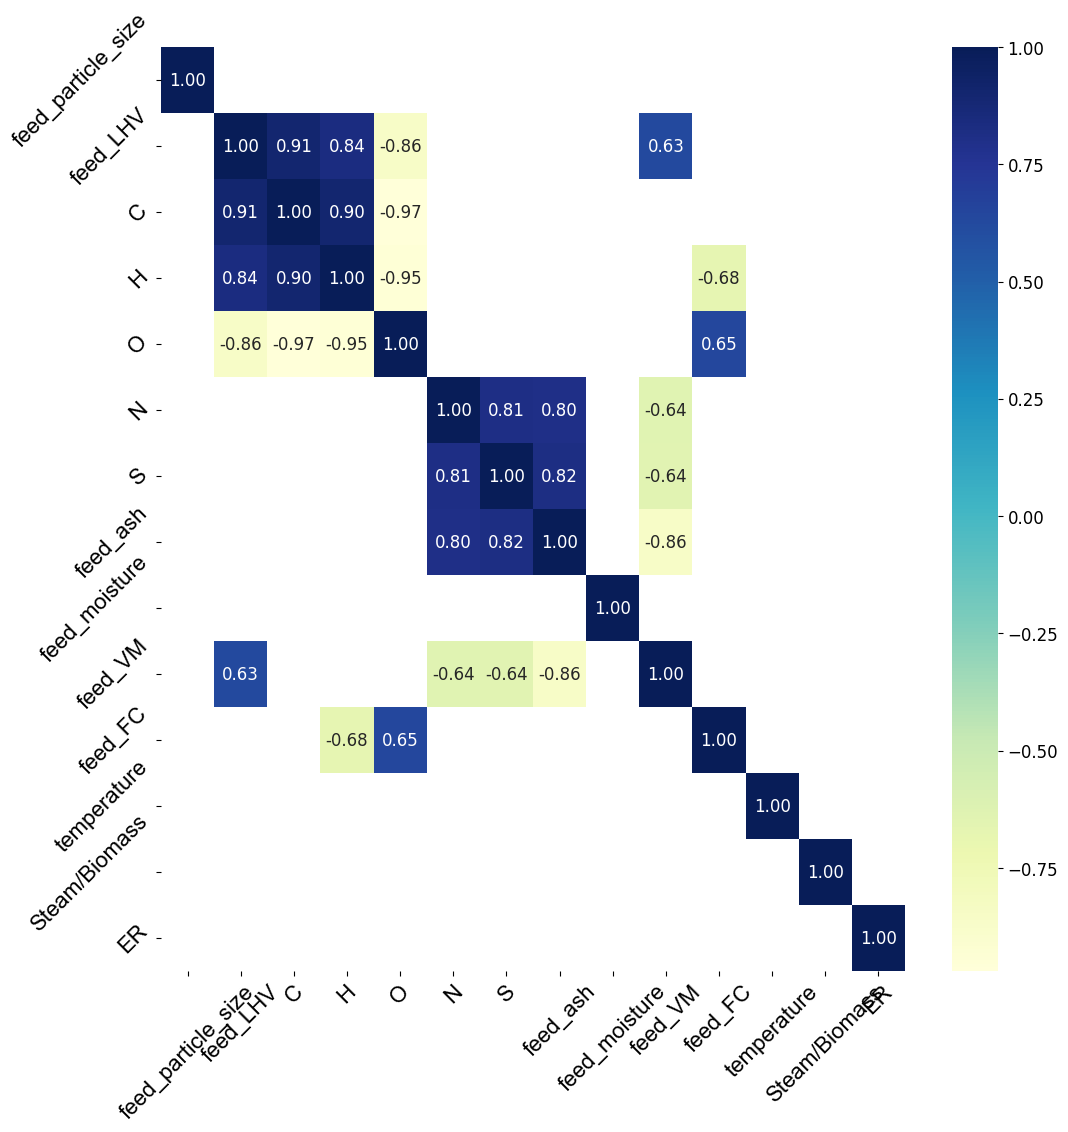


 Spearman correlation coefficient for continous predictor variables


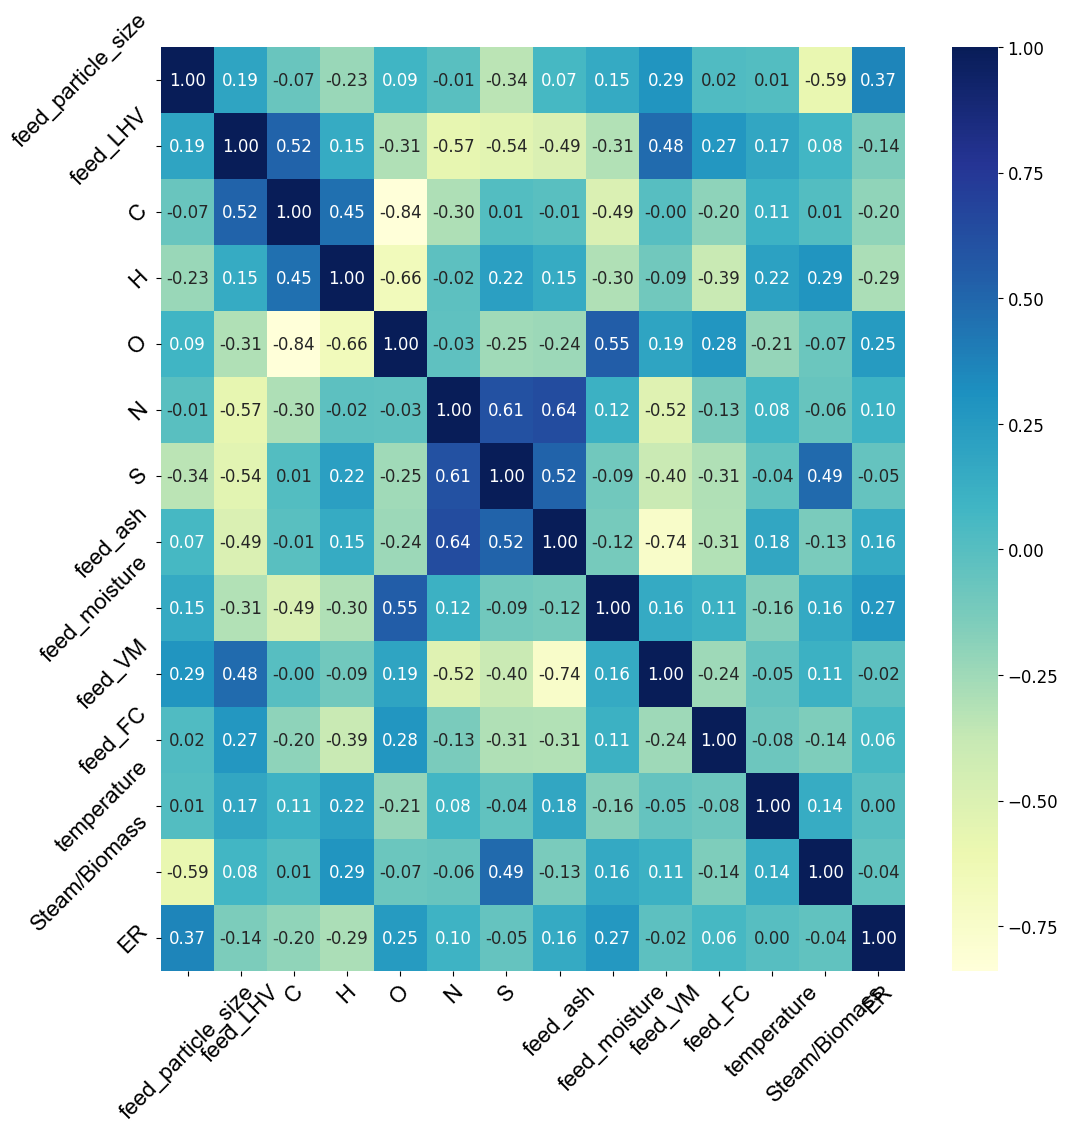

Show highly correlated values with an absolute value greater than 0.6 only


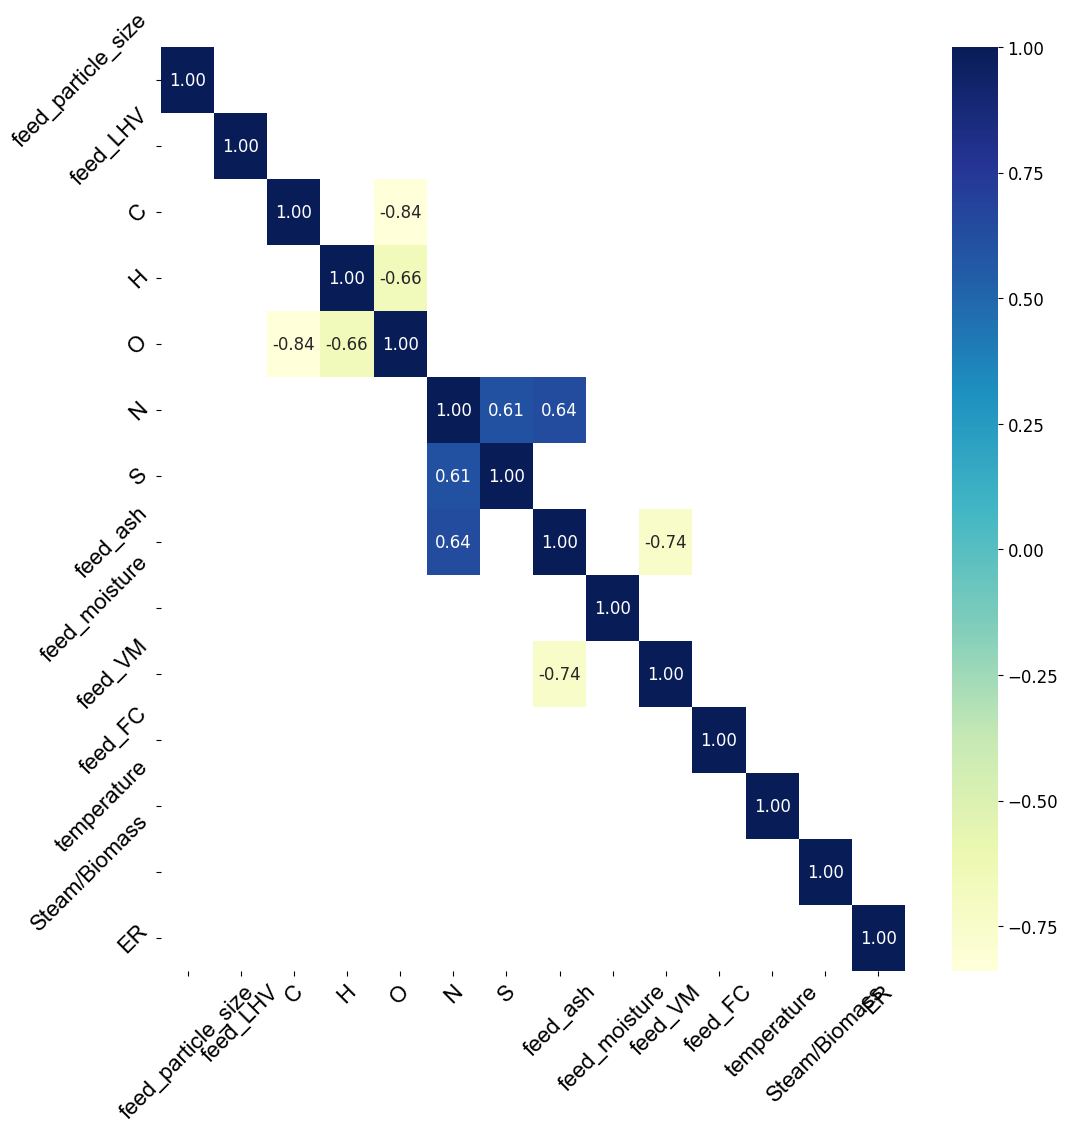

In [13]:
# Plot correlation between continous predictor variables

# Show Pearson correlation coefficients matrix

plt.rcParams.update({'font.size': 12})
rotation_angle = 45

print('Pearson correlation coefficient for continous predictor variables') # to avoid adding titles to figure
plt.figure(figsize=(12,12))
sns.heatmap(clean_input_cont.corr(method='pearson'), annot=True, cmap="YlGnBu", fmt=".2f")
plt.xticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.yticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.show()

# Repeat figure but this time show highly correlated factors ONLY
print('Show highly correlated values with an absolute value greater than {0} only'.format(pearson_corr_threshold))
plt.figure(figsize=(12,12))
pred_pearson_corr = clean_input_cont.corr(method='pearson')
sns.heatmap(pred_pearson_corr[abs(pred_pearson_corr)>=pearson_corr_threshold], annot=True, cmap="YlGnBu", fmt=".2f")
plt.xticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.yticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.show()

# Also show spearman correlation coefficients matrix
print('\n Spearman correlation coefficient for continous predictor variables') # to avoid adding titles to figure
plt.figure(figsize=(12,12))
sns.heatmap(clean_input_cont.corr(method='spearman'), annot=True, cmap="YlGnBu", fmt=".2f")
plt.xticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.yticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
#plt.savefig('figures\Spearman Correlation Matrices\Spearman_Correlation_Coefficient_Matrix.png', dpi=500)
plt.show()

# Repeat figure but this time show highly correlated factors ONLY
print('Show highly correlated values with an absolute value greater than {0} only'.format(spearman_corr_threshold))
plt.figure(figsize=(12,12))
pred_spearman_corr = clean_input_cont.corr(method='spearman')
sns.heatmap(pred_spearman_corr[abs(pred_spearman_corr)>=spearman_corr_threshold], annot=True, cmap="YlGnBu", fmt=".2f")
plt.xticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.yticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
#plt.savefig('figures\Spearman Correlation Matrices\Spearman_Correlation_Coefficient_Matrix_HighOnly.png', dpi=500)
plt.show()

In [16]:
clean_input_cat.isna().sum()

feed_type                0
feed_shape               0
operating_condition     10
gasifying_agent          0
reactor_type             0
bed_material           160
catalyst               100
scale                   19
dtype: int64

In [22]:
clean_input_cat.columns = ["Feedstock type", "Feedstock shape", "Operating condition (Batch/Continuous)", 'Gasifying agent', 'Reactor type', 'Bed material', 'Catalyst (Y/N)', 'Scale (lab/pilot)']
print(clean_input_cat.columns)

for i in clean_input_cat.columns:
    print(f'Categorical of {i} are: {clean_input_cat[i].unique()}')

Index(['Feedstock type', 'Feedstock shape',
       'Operating condition (Batch/Continuous)', 'Gasifying agent',
       'Reactor type', 'Bed material', 'Catalyst (Y/N)', 'Scale (lab/pilot)'],
      dtype='object')
Categorical of Feedstock type are: ['municipal solid waste' 'plastics' 'herbaceous biomass' 'woody biomass'
 'sewage sludge' 'other']
Categorical of Feedstock shape are: ['pellets' 'fibres' 'dust' 'other' 'chips' 'particles']
Categorical of Operating condition (Batch/Continuous) are: ['continuous' 'batch' nan]
Categorical of Gasifying agent are: ['air' 'air + steam' 'oxygen' 'steam' 'other' 'air/steam' 'steam/oxygen']
Categorical of Reactor type are: ['fluidised bed' 'fixed bed' 'other' 'horizontal tube'
 'bubbling fluidised bed']
Categorical of Bed material are: ['olivine' 'silica' 'dolomite' nan 'alumina' 'alumina ' 'sand']
Categorical of Catalyst (Y/N) are: [ 1.  0. nan]
Categorical of Scale (lab/pilot) are: ['pilot-scale (400 kW_th)' 'pilot-scale (500 kW_th)' 'pilot-scale'

In [50]:
input_cat_preprocessed = clean_input_cat.copy()

input_cat_preprocessed['Operating condition (Batch/Continuous)'] = input_cat_preprocessed['Operating condition (Batch/Continuous)'].fillna(input_cat_preprocessed['Operating condition (Batch/Continuous)'].mode().iloc[0])

input_cat_preprocessed['Gasifying agent'] = input_cat_preprocessed['Gasifying agent'].replace('air + steam', 'air/steam')

input_cat_preprocessed['Catalyst (Y/N)'] = input_cat_preprocessed['Catalyst (Y/N)'].fillna(input_cat_preprocessed['Catalyst (Y/N)'].mode().iloc[0])

input_cat_preprocessed['Scale (lab/pilot)'] = input_cat_preprocessed['Scale (lab/pilot)'].replace(['pilot-scale (400 kW_th)', 'pilot-scale (500 kW_th)', 'pilot-scale','100 kW_th', '127 kW', 'pilot-scale (~800kW)', '350 kw_th', '100 kW'], 'pilot-scale')
input_cat_preprocessed['Scale (lab/pilot)'] = input_cat_preprocessed['Scale (lab/pilot)'].replace(['small-scale (smaller than pilot)', 'laboratory scale', 'laboratory scale (20 kW_th)', 'bench-scale'], 'lab-scale')
input_cat_preprocessed['Scale (lab/pilot)'] = input_cat_preprocessed['Scale (lab/pilot)'].fillna(input_cat_preprocessed['Scale (lab/pilot)'].mode().iloc[0])

In [51]:
input_cat_preprocessed['Scale (lab/pilot)'].unique()

array(['pilot-scale', 'lab-scale'], dtype=object)

In [15]:
clean_input_cont.isna().sum()

feed_particle_size     42
feed_LHV                0
C                       0
H                       0
O                       0
N                       0
S                      33
feed_ash                0
feed_moisture           0
feed_VM                48
feed_FC                90
temperature             0
Steam/Biomass         272
ER                     73
dtype: int64